In [1]:
%env TORCH_HOME=/mnt/home/mizrahiulysse/model_cache/torch

from elasticdino.model.elasticdino import ElasticDino
from elasticdino.training.depth.train_depth import make_pretraining_dataloader, train_parallel, abs_depth_to_image
from elasticdino.training.depth.layers import DPTDepthModel, ElasticDinoDepthModel, ElasticDinoDepthModel2
from elasticdino.model.dino import DinoV2
from elasticdino.data.imagenet import load_imagenet
import torch
import os
from datetime import datetime


%load_ext autoreload 
%autoreload 2

    
torch.set_float32_matmul_precision('high')

MODEL = "ED"

def remove_model_prefix(d):
  """
  Recursively removes the prefix "module." from dictionary keys.

  :param d: The dictionary to process.
  :return: A new dictionary with updated keys.
  """
  if not isinstance(d, dict):
    return d

  new_dict = {}
  for key, value in d.items():
    new_key = key
    if key.startswith("module."):
      new_key = key[7:]  # Remove the prefix "model."

    # Recursively process nested dictionaries or lists
    if isinstance(value, dict):
      new_dict[new_key] = remove_model_prefix(value)
    elif isinstance(value, list):
      new_dict[new_key] = [remove_model_prefix(item) for item in value]
    else:
      new_dict[new_key] = value

  return new_dict

def get_model():
    if MODEL == "DPT":
      dino = DinoV2("l")
      model = DPTDepthModel(512, dino, 128)
    elif MODEL == "ED":
      ed = ElasticDino.from_pretrained("/mnt/home/mizrahiulysse/pixelvit-32-L.pth", "elasticdino-32-L")
      ed.eval()
      ed.requires_grad_ = False
      model = ElasticDinoDepthModel2(ed, 512, [64, 64, 128, 256])
    else:
      raise Exception("Unknown model")
    CHECKPOINT = None # os.environ.get("CHECKPOINT", None)
    if CHECKPOINT is not None:
      model.load_state_dict(remove_model_prefix(torch.load(CHECKPOINT, weights_only=True)))
    return model


PARALLEL = True
BATCH_SIZE = 16

env: TORCH_HOME=/mnt/home/mizrahiulysse/model_cache/torch


In [2]:
import torch.nn as nn
from elasticdino.training.depth.train_depth import si_log_loss, get_optimizers, init_run, accumulate_losses, debug_step
from accelerate.utils import write_basic_config
from accelerate import Accelerator
from accelerate.utils import set_seed, DistributedDataParallelKwargs



Launching training on 2 GPUs.


Using cache found in /mnt/home/mizrahiulysse/model_cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /mnt/home/mizrahiulysse/model_cache/torch/hub/facebookresearch_dinov2_main
/mnt/home/mizrahiulysse/model_cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/mnt/home/mizrahiulysse/model_cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/mnt/home/mizrahiulysse/model_cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/mnt/home/mizrahiulysse/model_cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attenti

Loading imagenet
Loading imagenet


/mnt/projects/conda-envs/dgxenv-2025-03-11-12-05-50-x9989-centos9-310-pt251cf-4/lib/python3.10/site-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


Imagenet loaded


/mnt/projects/conda-envs/dgxenv-2025-03-11-12-05-50-x9989-centos9-310-pt251cf-4/lib/python3.10/site-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


Imagenet loaded
Start trainingStart training

EpochEpoch  0
0loading depth anything

loading depth anything


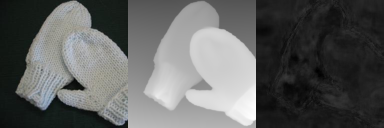

50	5.685173511505127	10.0


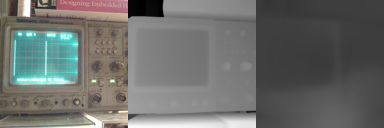

100	4.914950370788574	10.0


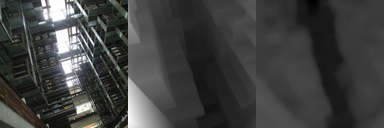

150	2.5826854705810547	10.0


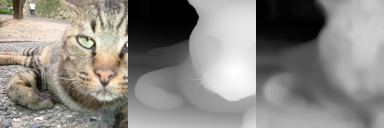

200	1.6293224096298218	10.0


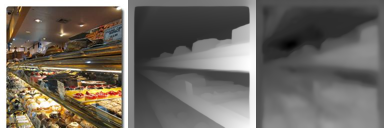

250	1.3002853393554688	10.0


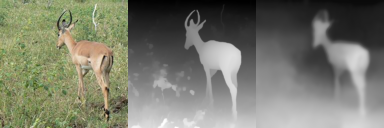

300	1.124091625213623	10.0


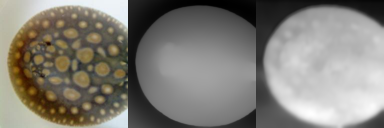

350	0.9858778119087219	10.0


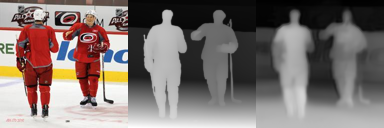

400	0.9665281176567078	9.99068546295166


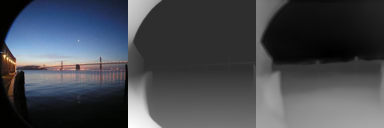

450	0.9827091097831726	9.996607780456543


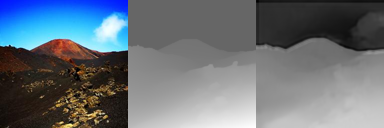

500	0.9381227493286133	9.998764991760254


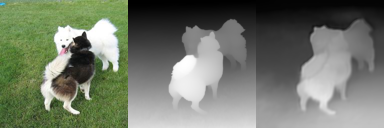

550	0.9578877687454224	9.999550819396973


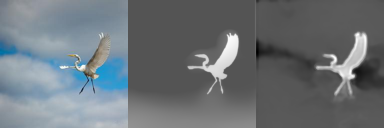

600	0.9117109775543213	9.999836921691895


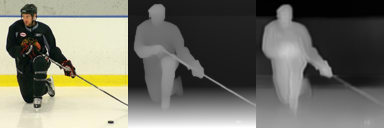

650	0.9164005517959595	9.999938011169434


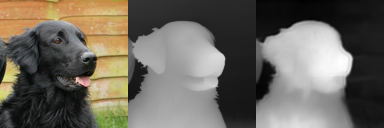

700	0.8965187072753906	9.99997615814209


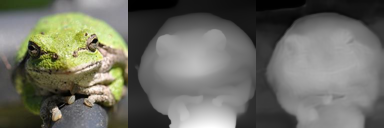

750	0.8823531270027161	9.99997615814209


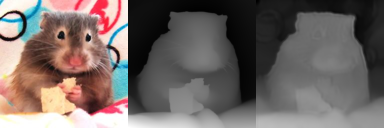

800	0.8416605591773987	9.903319358825684


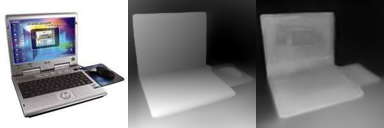

850	0.8951976895332336	9.964792251586914


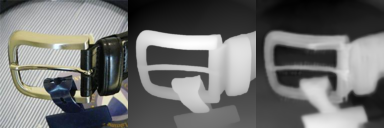

900	0.8476206064224243	9.987178802490234


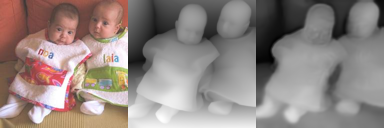

950	0.8994537591934204	9.995331764221191


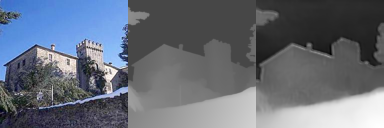

1000	0.9043889045715332	9.778255462646484


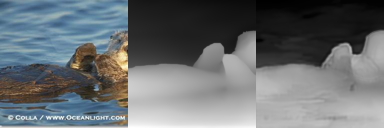

1050	0.8434579372406006	9.919246673583984


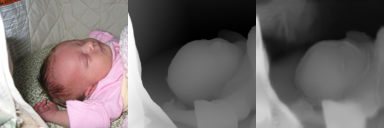

1100	0.8080313205718994	9.938655853271484


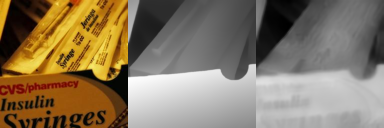

1150	0.8554120659828186	9.833340644836426


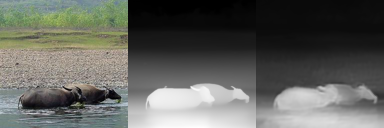

1200	0.8322249054908752	9.939308166503906


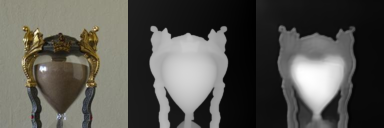

1250	0.9096561074256897	9.977898597717285


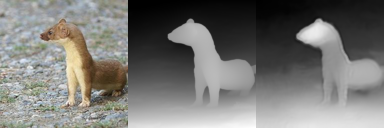

1300	0.8899309635162354	9.96688175201416


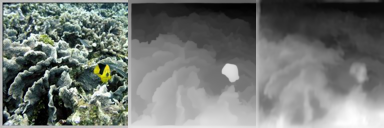

1350	0.8435540199279785	9.987939834594727


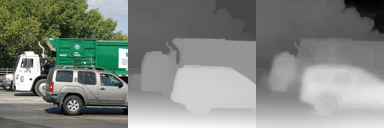

1400	0.829289436340332	9.904715538024902


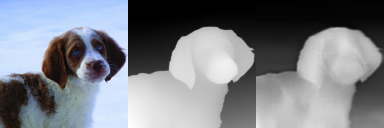

1450	0.8455060720443726	9.865148544311523


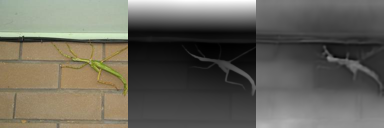

1500	0.8124614357948303	9.895004272460938


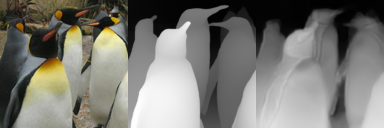

1550	0.7983019948005676	9.817867279052734


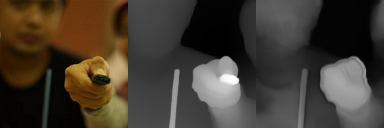

1600	0.814583957195282	9.926774978637695


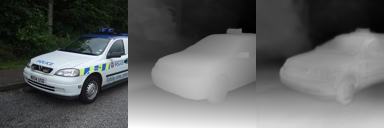

1650	0.837089478969574	9.973331451416016


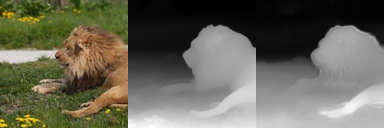

1700	0.8036951422691345	9.7689847946167


In [ ]:
BITS_AND_BYTES = False
BATCH_SIZE = 16
from IPython.display import display

def get_dataloader():
    dataloader = load_imagenet("/mnt/home/mizrahiulysse/datasets/imagenet-1k-256/imagenet/test", BATCH_SIZE, image_size=128)
    depth_dataloader = make_pretraining_dataloader(dataloader, "/mnt/home/mizrahiulysse/model_cache/depth_anything_v2_large/", True)
    return depth_dataloader
    
def get_optimizers(model, dataloader, lr, accelerator=None):
  optimizer_class = bitsandbytes.optim.AdamW8bit if BITS_AND_BYTES else torch.optim.AdamW
  optimizer = optimizer_class(
[      {"params": model.parameters(), "lr": lr}], eps=1e-5, weight_decay=0.03)

  def lr_lambda(epoch):
    return 1
    # return math.pow(10, - epoch / decay_period)
  scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
  if accelerator is not None:
      model, dataloader, optimizer, scheduler = accelerator.prepare(model, dataloader, optimizer, scheduler)
  return model, dataloader, optimizer, scheduler

import numpy as np

import torchvision
from PIL import Image

def debug_step(run_folder, batch, results, running_loss, running_mre, n, display_size):
  with torch.no_grad():
    images = [torchvision.transforms.functional.to_pil_image(batch["images"][0])]
    depths = abs_depth_to_image(batch, results, display_size)
    images.append(depths)
    debug_image = Image.fromarray(np.hstack(images).astype(np.uint8))
    if run_folder is not None:
        debug_image.save(f"{run_folder}/images/{n}.jpg")
    else:
        display(debug_image)
    line = [str(x) for x in [n, running_loss.item(), running_mre.item()]]
    line = "\t".join(line)
    print(line)
    if run_folder is not None:
        with open(f"{run_folder}/training_loss.txt", "a+") as f:
          print("writing to", f"{run_folder}/training_loss.txt")
          f.write(line + "\n")
        
def train_parallel(
        get_dataloader,
        get_model,
        train_config):

  set_seed(42)
  kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
  accelerator = Accelerator(mixed_precision="fp16", kwargs_handlers=[kwargs])

  n_epochs = train_config.get("n_epochs", 1)
  lr = train_config.get("lr", 1e-4)
  decay_period = train_config.get("decay_period", 5000)
  n_epochs = train_config.get("n_epochs", 1)
  max_iterations = train_config.get("max_iterations", None)
  debug_interval = train_config.get("debug_interval", 50)
  save_interval = train_config.get("save_interval", 1000)
  display_size = train_config.get("display_size", 128)
  project_folder = train_config["project_folder"]

  
  model = get_model().cuda()
  dataloader = get_dataloader()
  loss_fn = si_log_loss

  run_folder = init_run(project_folder) if project_folder is not None else None
  model, dataloader, optimizer, scheduler = get_optimizers(model, dataloader, lr, accelerator)
    
  running_loss = None
  running_mre = None
  n = 0

  print("Start training")
  for epoch in range(n_epochs):
    print("Epoch", epoch)
    for batch in dataloader:
        if n == max_iterations:
          return
        n += 1
        with accelerator.autocast():
            predicted = model(batch["images"])
            loss = si_log_loss(predicted.clamp(1e-4, 100), batch["depths"].clamp(1e-4, 100))
        accelerator.backward(loss)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        running_loss, running_mre = accumulate_losses(batch, predicted, 1, loss, running_loss, running_mre)
        
        if n % debug_interval == 0 and accelerator.is_local_main_process:
          debug_step(run_folder, batch, predicted, running_loss, running_mre, n, display_size)

        if n % save_interval == 0 and run_folder is not None:
          accelerator.save_state( f"{run_folder}/checkpoints/{n}")


        del batch
        del loss
        del predicted
        
from accelerate import notebook_launcher

train_config = dict(
  n_epochs=2,
  # max_iterations=10,
  lr = 1e-3,
  decay_period=5000,
  accumulation=1,
  debug_interval=50,
  save_interval=5,
  display_size=128, 
  project_folder=None# f"/mnt/home/mizrahiulysse/elasticdino-runs/pretrain-elasticdino-depth/{MODEL}"
)

args = (get_dataloader, get_model, train_config)
notebook_launcher(
  train_parallel,
  args,
  num_processes=2
)